In [ ]:
lab6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
USAhousing = pd.read_csv('USA_Housing.csv')

In [3]:
USAhousing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 37010-5101"
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA 48958"
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482-3489"
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
USAhousing.info()

Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                             str
dtype: object

Shape: (5000, 7)


In [5]:
USAhousing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [6]:
USAhousing.columns

['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']

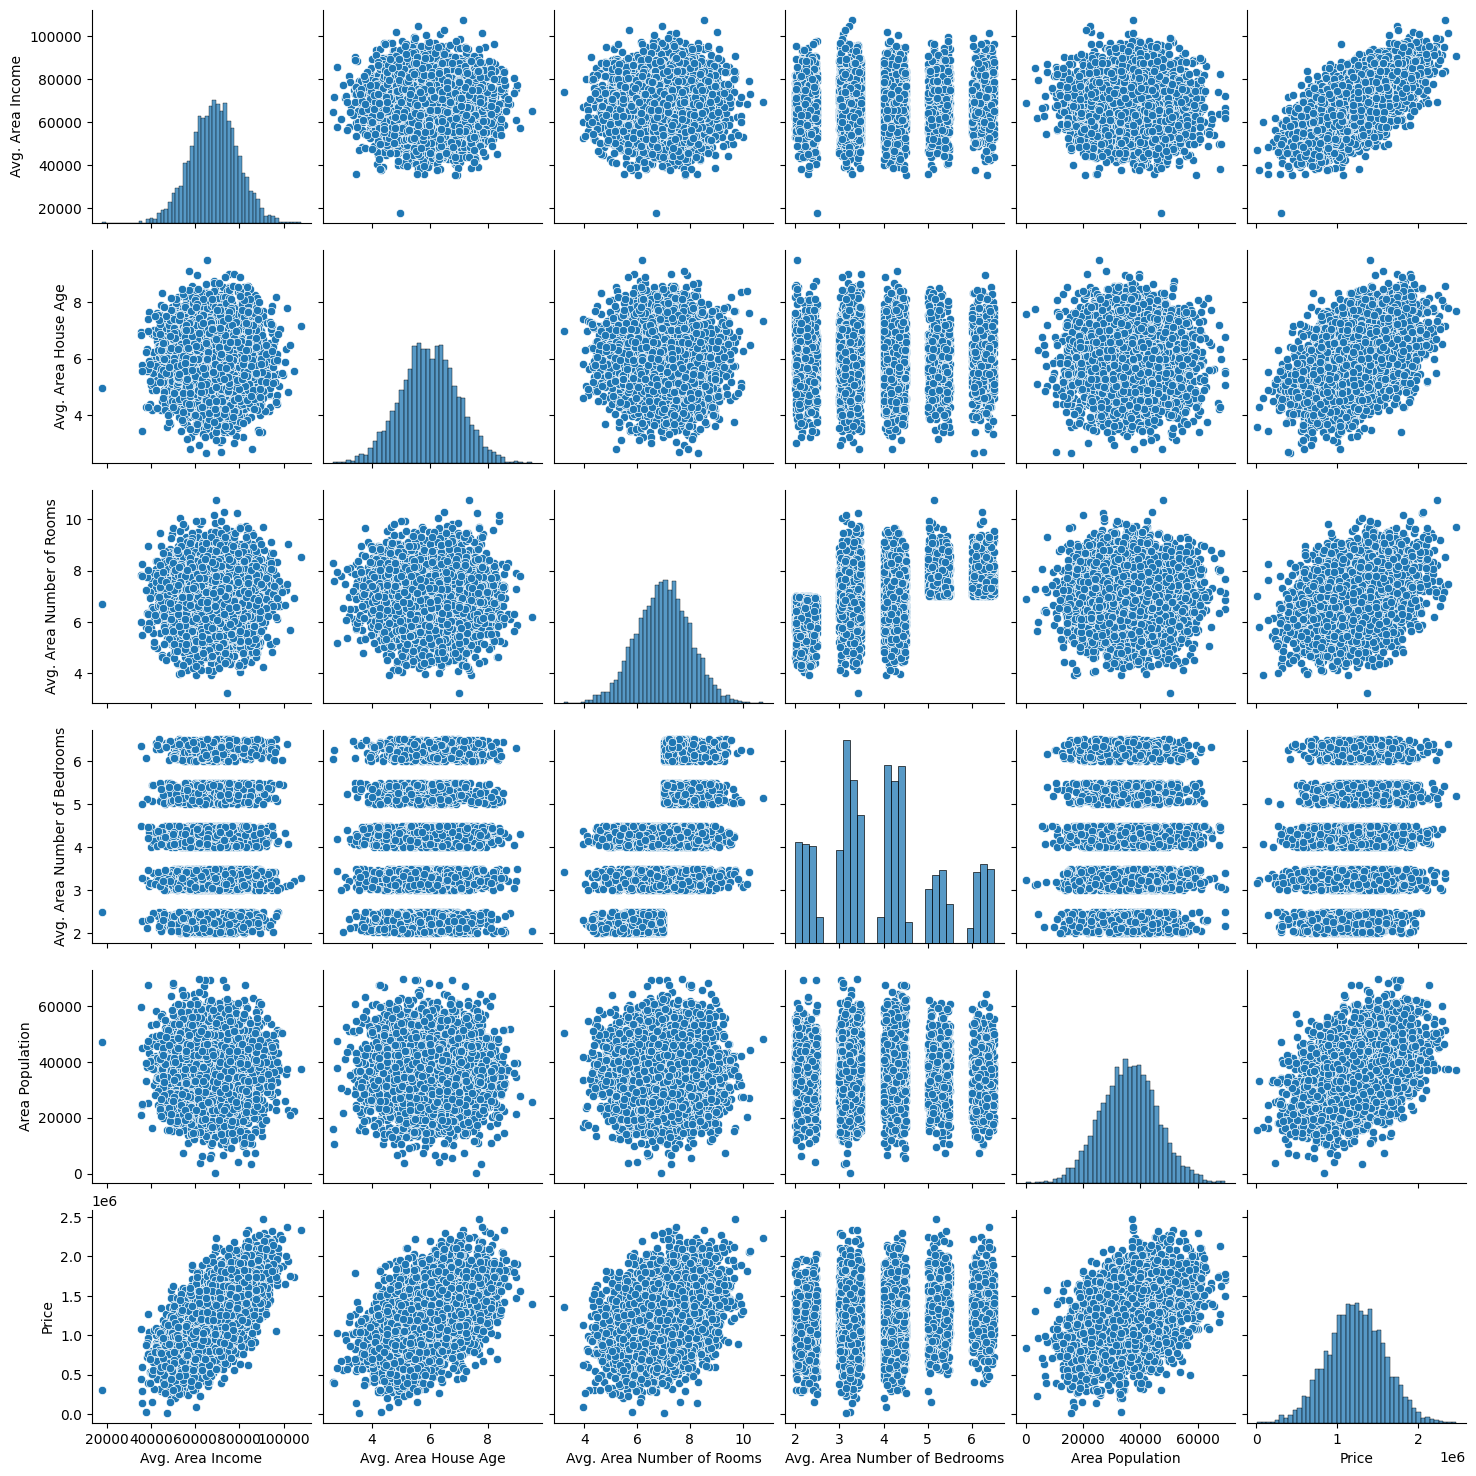

In [7]:
sns.pairplot(USAhousing)

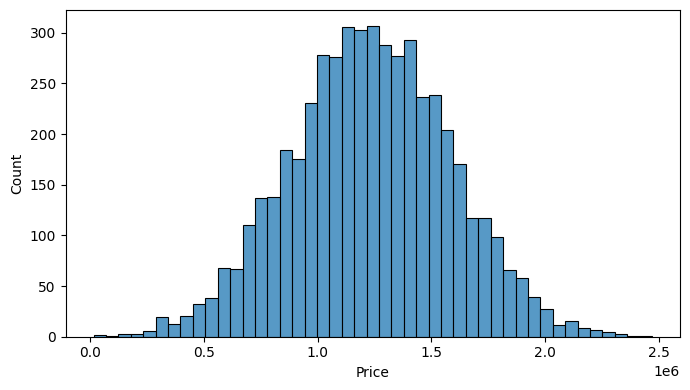

In [8]:
#sns.distplot(USAhousing['Price'])
sns.histplot(USAhousing['Price'])

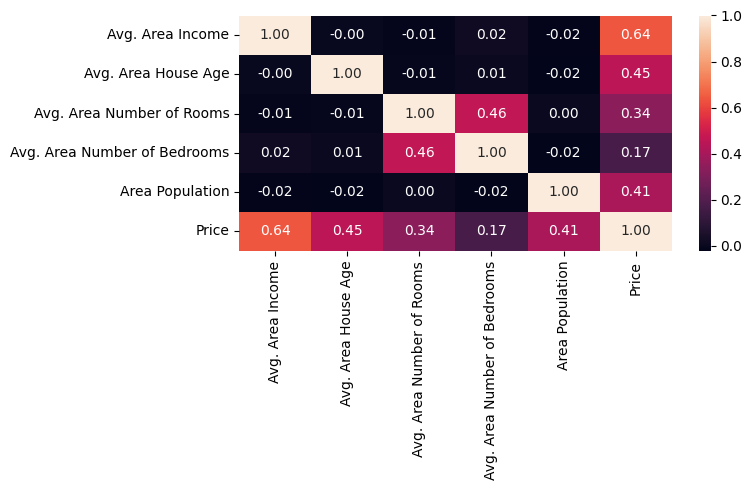

In [9]:
#sns.heatmap(USAhousing.corr()) this function produced 
sns.heatmap(USAhousing.select_dtypes(include='number').corr())

In [10]:
X = USAhousing[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population']]
y = USAhousing['Price']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

X_train: (3000, 5), X_test: (2000, 5)


In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lm = LinearRegression()

In [15]:
lm.fit(X_train,y_train)

LinearRegression()

In [16]:
# print the intercept
print(lm.intercept_)

-2640159.796853


In [17]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Avg. Area Income,21.528276
Avg. Area House Age,164883.282027
Avg. Area Number of Rooms,122368.678027
Avg. Area Number of Bedrooms,2233.801864
Area Population,15.150420


    from sklearn.datasets import load_boston
    boston = load_boston()
    print(boston.DESCR)
    boston_df = boston.data

In [18]:
predictions = lm.predict(X_test)

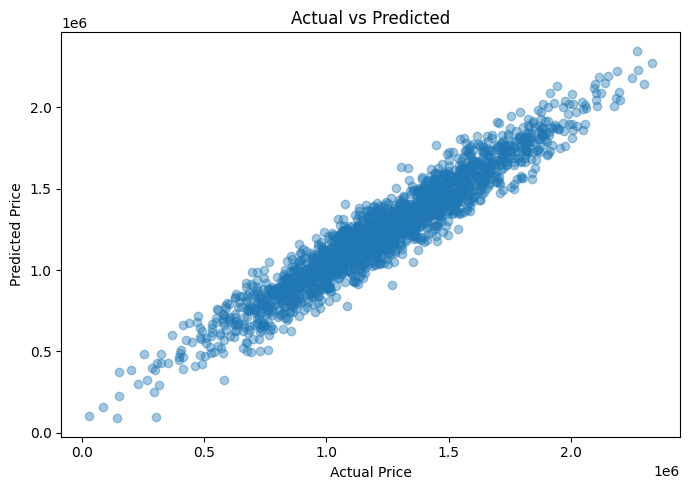

In [19]:
plt.scatter(y_test,predictions)

**Residual Histogram**

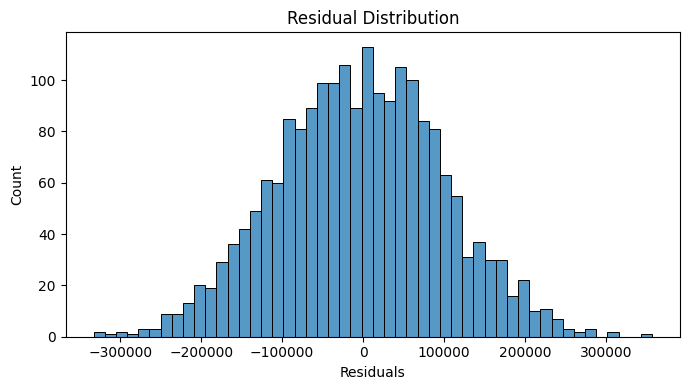

In [20]:
sns.histplot((y_test-predictions),bins=50);

In [21]:
from sklearn import metrics

In [22]:
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

In [23]:
# Task: Load Ecommerce Customers dataset
ecomm = pd.read_csv('Ecommerce_Customers')
ecomm.head(10)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, DC 99414-7564",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 37242-1057",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
5,alvareznancy@lucas.biz,"645 Martha Park Apt. 611\nJeffreychester, MN 67218-7250",FloralWhite,33.871038,12.026925,34.476878,5.493507,637.102448
6,katherine20@yahoo.com,"68388 Reyes Lights Suite 692\nJosephbury, WV 92213-0247",DarkSlateBlue,32.021596,11.366348,36.683776,4.685017,521.572175
7,awatkins@yahoo.com,Unit 6538 Box 8980\nDPO AP 09026-4941,Aqua,32.739143,12.351959,37.373359,4.434273,549.904146
8,vchurch@walter-martinez.com,"860 Lee Key\nWest Debra, SD 97450-0495",Salmon,33.987773,13.386235,37.534497,3.273434,570.200409
9,bonnie69@lin.biz,"PSC 2734, Box 5255\nAPO AA 98456-7482",Brown,31.936549,11.814128,37.145168,3.202806,427.199385


In [24]:
ecomm.info()

RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 Email                 500 non-null    object
 Address               500 non-null    object
 Avatar                500 non-null    object
 Avg. Session Length   500 non-null    float64
 Time on App           500 non-null    float64
 Time on Website       500 non-null    float64
 Length of Membership  500 non-null    float64
 Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
No missing values.


In [25]:
ecomm.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


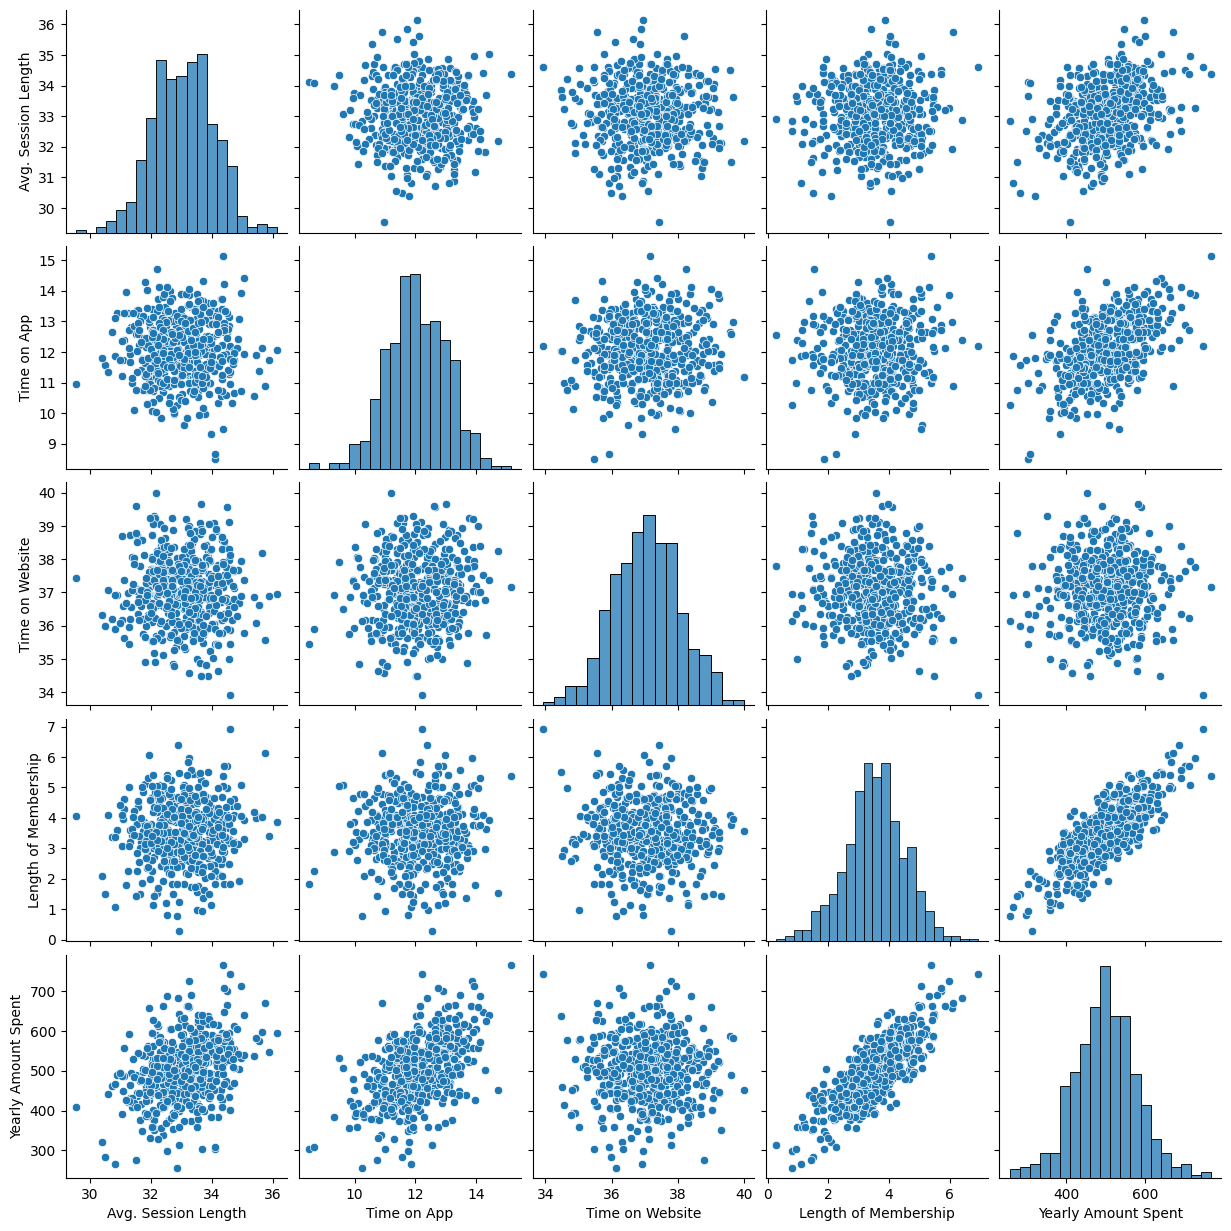

In [26]:
# EDA - pairplot on numeric columns
sns.pairplot(ecomm[['Avg. Session Length','Time on App','Time on Website','Length of Membership','Yearly Amount Spent']])

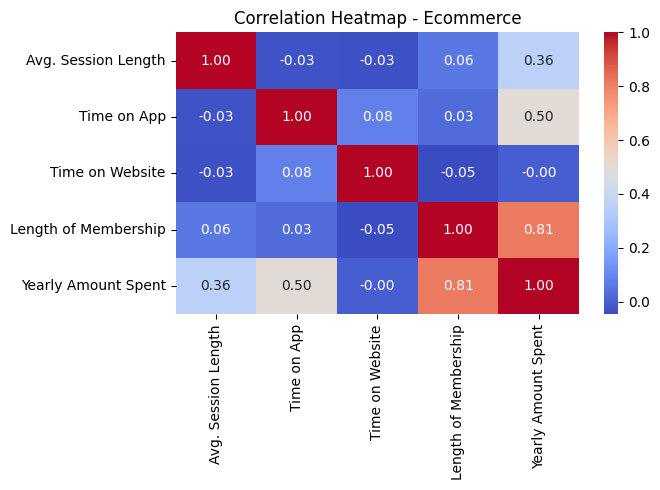

In [27]:
# Correlation heatmap
plt.figure(figsize=(7,5))
sns.heatmap(ecomm[['Avg. Session Length','Time on App','Time on Website','Length of Membership','Yearly Amount Spent']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Ecommerce')
plt.tight_layout()
plt.show()

In [28]:
# Feature engineering
ecomm_fe = ecomm.copy()
ecomm_fe['App_to_Web_Ratio'] = ecomm_fe['Time on App'] / ecomm_fe['Time on Website']
ecomm_fe['Total_Engagement'] = ecomm_fe['Avg. Session Length'] + ecomm_fe['Time on App'] + ecomm_fe['Time on Website']
ecomm_fe[['Avg. Session Length','Time on App','Time on Website','Length of Membership','App_to_Web_Ratio','Total_Engagement','Yearly Amount Spent']].head(10)

,Avg. Session Length,Time on App,Time on Website,Length of Membership,App_to_Web_Ratio,Total_Engagement,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,0.319767,86.730587,587.951054
1,31.926272,11.109461,37.268959,2.664034,0.298089,80.304692,392.204933
2,33.000915,11.330278,37.110597,4.104543,0.305311,81.441790,487.547505
3,34.305557,13.717514,36.721283,3.120179,0.373558,84.744353,581.852344
4,33.330673,12.795189,37.536653,4.446308,0.340872,83.662514,599.406092
5,33.871038,12.026925,34.476878,5.493507,0.348840,80.374841,637.102448
6,32.021596,11.366348,36.683776,4.685017,0.309847,80.071720,521.572175
7,32.739143,12.351959,37.373359,4.434273,0.330502,82.464461,549.904146
8,33.987773,13.386235,37.534497,3.273434,0.356638,84.908506,570.200409
9,31.936549,11.814128,37.145168,3.202806,0.318053,80.895845,427.199385


In [29]:
# Prepare data for modeling
X_e = ecomm_fe[['Avg. Session Length','Time on App','Time on Website','Length of Membership','App_to_Web_Ratio','Total_Engagement']]
y_e = ecomm_fe['Yearly Amount Spent']
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_e, y_e, test_size=0.3, random_state=101)
print(f'X_train: {X_train_e.shape}, X_test: {X_test_e.shape}')

X_train: (350, 6), X_test: (150, 6)


In [30]:
# Train Linear Regression model
lm_e = LinearRegression()
lm_e.fit(X_train_e, y_train_e)

LinearRegression()

In [31]:
# Coefficients
print('Intercept:', lm_e.intercept_)
coeff_e = pd.DataFrame(lm_e.coef_, X_e.columns, columns=['Coefficient'])
coeff_e

Intercept: -1131.8655


,Coefficient
Avg. Session Length,10.964613
Time on App,16.622300
Time on Website,-12.567010
Length of Membership,61.284508
App_to_Web_Ratio,257.264828
Total_Engagement,15.019903


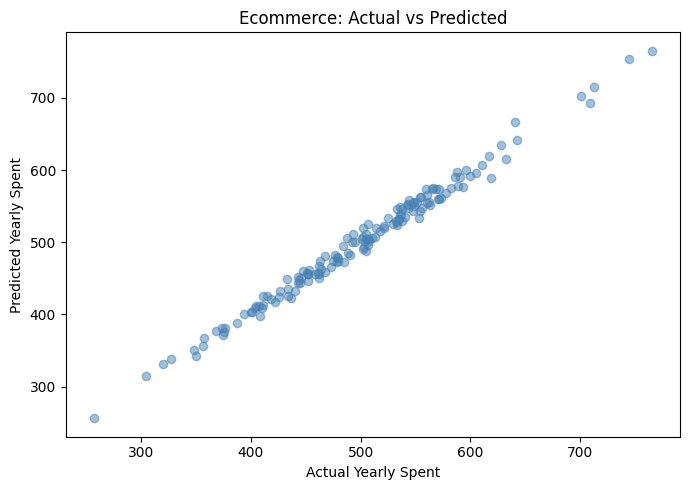

In [32]:
# Predictions
preds_e = lm_e.predict(X_test_e)
plt.scatter(y_test_e, preds_e, alpha=0.5, color='steelblue')
plt.xlabel('Actual Yearly Spent')
plt.ylabel('Predicted Yearly Spent')
plt.title('Ecommerce: Actual vs Predicted')
plt.tight_layout()
plt.show()

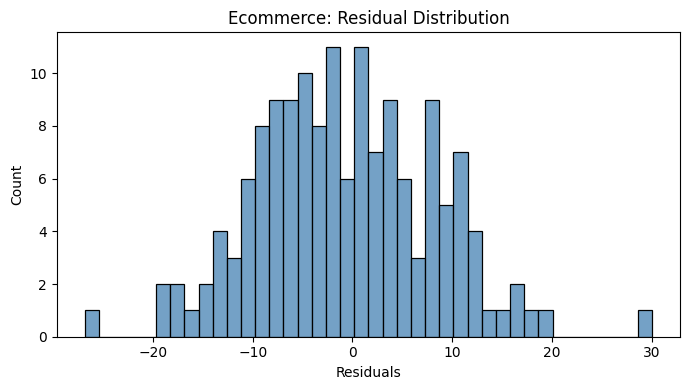

In [33]:
# Residual plot
sns.histplot((y_test_e - preds_e), bins=40, color='steelblue')
plt.xlabel('Residuals')
plt.title('Ecommerce: Residual Distribution')
plt.tight_layout()
plt.show()

In [34]:
# Model evaluation
print('MAE: ', metrics.mean_absolute_error(y_test_e, preds_e))
print('MSE: ', metrics.mean_squared_error(y_test_e, preds_e))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test_e, preds_e)))
print('R2:  ', metrics.r2_score(y_test_e, preds_e))

MAE:  7.1956
MSE:  79.2818
RMSE: 8.9040
R2:   0.9891
